In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/train.csv
/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/test.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/train.csv")

In [3]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [4]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
X = df.drop('price_range', axis=1)
y = df['price_range']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [8]:
model1 = DecisionTreeClassifier()

In [9]:
model1.fit(X_train, y_train)

DecisionTreeClassifier()

In [10]:
model1.score(X_test, y_test)

0.8227272727272728

In [11]:
model = DecisionTreeClassifier(criterion='entropy')

In [12]:
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [13]:
model.score(X_test, y_test)

0.8287878787878787

In [14]:
model3 = DecisionTreeClassifier(criterion='log_loss')

In [15]:
model3.fit(X_train, y_train)

DecisionTreeClassifier(criterion='log_loss')

In [16]:
model3.score(X_test, y_test)

0.8333333333333334

In [17]:
model_forest = RandomForestClassifier(n_estimators=50)

In [18]:
model_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50)

In [19]:
model_forest.score(X_test, y_test)

0.8606060606060606

In [20]:
model_forest1 = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=None)

In [21]:
model_forest1.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy')

In [22]:
model_forest1.score(X_test, y_test)

0.8833333333333333

In [23]:
model_forest2 = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=None, bootstrap=True)

In [24]:
model_forest2.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy')

In [25]:
model_forest2.score(X_test, y_test)

0.8909090909090909

In [26]:
from sklearn.ensemble import AdaBoostClassifier,BaggingClassifier,GradientBoostingClassifier,StackingClassifier,VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [27]:
clf_log = LogisticRegression(max_iter=10000)
clf_tree = DecisionTreeClassifier(criterion='entropy')

In [28]:
voting_model = VotingClassifier(estimators=[('log',clf_log),('dt',clf_tree)], voting='hard')

In [29]:
voting_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('log', LogisticRegression(max_iter=10000)),
                             ('dt',
                              DecisionTreeClassifier(criterion='entropy'))])

In [30]:
voting_model.score(X_test, y_test)

0.8318181818181818

In [31]:
voting_model1 = VotingClassifier(estimators=[('log',clf_log),('dt',clf_tree)], voting='soft')

In [32]:
voting_model1.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('log', LogisticRegression(max_iter=10000)),
                             ('dt',
                              DecisionTreeClassifier(criterion='entropy'))],
                 voting='soft')

In [33]:
voting_model1.score(X_test, y_test)

0.8212121212121212

In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [35]:
clf_knn = KNeighborsClassifier(n_neighbors=7)

In [36]:
voting_model2 = VotingClassifier(estimators=[('log',clf_log),('dt',clf_tree),('knn', clf_knn)], voting='hard')

In [37]:
voting_model2.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('log', LogisticRegression(max_iter=10000)),
                             ('dt',
                              DecisionTreeClassifier(criterion='entropy')),
                             ('knn', KNeighborsClassifier(n_neighbors=7))])

In [38]:
voting_model2.score(X_test, y_test)

0.9075757575757576

In [39]:
voting_model3 = VotingClassifier(estimators=[('log',clf_log),('dt',clf_tree),('knn', clf_knn)], voting='soft')

In [40]:
voting_model3.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('log', LogisticRegression(max_iter=10000)),
                             ('dt',
                              DecisionTreeClassifier(criterion='entropy')),
                             ('knn', KNeighborsClassifier(n_neighbors=7))],
                 voting='soft')

In [41]:
voting_model3.score(X_test, y_test)

0.8803030303030303

In [42]:
clf_rf = RandomForestClassifier(n_estimators=10)

In [43]:
voting_model4 = VotingClassifier(estimators=[('log',clf_log),('dt',clf_tree),('knn', clf_knn),('rf',clf_rf)], voting='soft')

In [44]:
voting_model4.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('log', LogisticRegression(max_iter=10000)),
                             ('dt',
                              DecisionTreeClassifier(criterion='entropy')),
                             ('knn', KNeighborsClassifier(n_neighbors=7)),
                             ('rf', RandomForestClassifier(n_estimators=10))],
                 voting='soft')

In [45]:
voting_model4.score(X_test, y_test)

0.8818181818181818

In [46]:
clf_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [47]:
clf_knn.score(X_test, y_test)

0.9272727272727272

In [48]:
df.corr()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


In [49]:
clf_log1 = LogisticRegression(max_iter=100)

In [50]:
X_train['ram'].to_numpy().reshape(-1,1)

array([[2593],
       [1518],
       [3744],
       ...,
       [2080],
       [2916],
       [2107]], shape=(1340, 1))

In [51]:
clf_log1.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [52]:
clf_log1.score(X_test, y_test)

0.6378787878787879

In [53]:
clf_log = LogisticRegression(max_iter=10000)
clf_tree = DecisionTreeClassifier(criterion='entropy')
clf_knn = KNeighborsClassifier(n_neighbors=7)
clf_rf = RandomForestClassifier(n_estimators=10)

In [54]:
Estimators = [('log',clf_log),('dt',clf_tree),('knn', clf_knn),('rf',clf_rf)]

In [55]:
st_model = StackingClassifier(estimators = Estimators, final_estimator =LogisticRegression() )

In [56]:
st_model

StackingClassifier(estimators=[('log', LogisticRegression(max_iter=10000)),
                               ('dt',
                                DecisionTreeClassifier(criterion='entropy')),
                               ('knn', KNeighborsClassifier(n_neighbors=7)),
                               ('rf', RandomForestClassifier(n_estimators=10))],
                   final_estimator=LogisticRegression())

In [57]:
st_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

StackingClassifier(estimators=[('log', LogisticRegression(max_iter=10000)),
                               ('dt',
                                DecisionTreeClassifier(criterion='entropy')),
                               ('knn', KNeighborsClassifier(n_neighbors=7)),
                               ('rf', RandomForestClassifier(n_estimators=10))],
                   final_estimator=LogisticRegression())

In [58]:
st_model.score(X_test, y_test)

0.9272727272727272

In [59]:
clf_bag = BaggingClassifier(estimator = KNeighborsClassifier(n_neighbors=7), n_estimators=10, random_state=0)

In [60]:
clf_bag.fit(X_train, y_train)

BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=7), random_state=0)

In [61]:
clf_bag.score(X_test, y_test)

0.9333333333333333

In [62]:
clf_Ada = AdaBoostClassifier(n_estimators=100) 

In [63]:
clf_Ada.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100)

In [64]:
clf_Ada.score(X_test, y_test)

0.7151515151515152

In [65]:
clf_XGB = XGBClassifier(n_estimators=10, max_depth=5, learning_rate=1, objective='binary:logistic')

In [66]:
clf_XGB.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, ...)

In [67]:
clf_XGB.score(X_test, y_test)

0.9015151515151515

In [68]:
clf_XGB1 = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, objective='binary:logistic')

In [69]:
clf_XGB1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [70]:
clf_XGB1.score(X_test, y_test)

0.9045454545454545

In [71]:
clf_XGB2 = XGBClassifier(n_estimators=1000, max_depth=10, learning_rate=5, objective='binary:logistic')

In [72]:
clf_XGB2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [73]:
clf_XGB2.score(X_test, y_test)

0.49696969696969695

In [74]:
clf_XGB3 = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=1, objective='binary:softmax')

In [75]:
clf_XGB3.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [76]:
clf_XGB3.score(X_test, y_test)

0.9151515151515152

In [77]:
from sklearn.model_selection import GridSearchCV

In [78]:
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}
grid_model = GridSearchCV(DecisionTreeClassifier(), param_grid, scoring=None, n_jobs=None, refit=True, cv=None, return_train_score=False)

In [79]:
grid_model.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [3, 5, 10],
                         'min_samples_split': [2, 5, 10]})

In [80]:
grid_model.score(X_test, y_test)

0.8378787878787879

In [81]:
voting_model5 = VotingClassifier(estimators=[('log',clf_log),('dt',clf_tree),('knn', clf_knn),('rf',clf_rf),('xgb', clf_XGB)], voting='hard')

In [82]:
voting_model5.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('log', LogisticRegression(max_iter=10000)),
                             ('dt',
                              DecisionTreeClassifier(criterion='entropy')),
                             ('knn', KNeighborsClassifier(n_neighbors=7)),
                             ('rf', RandomForestClassifier(n_estimators=10)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, devi...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=10, n_jobs=None,
                                            num_parallel_tree=None, ...))])

In [83]:
voting_model5.score(X_test, y_test)

0.9075757575757576

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

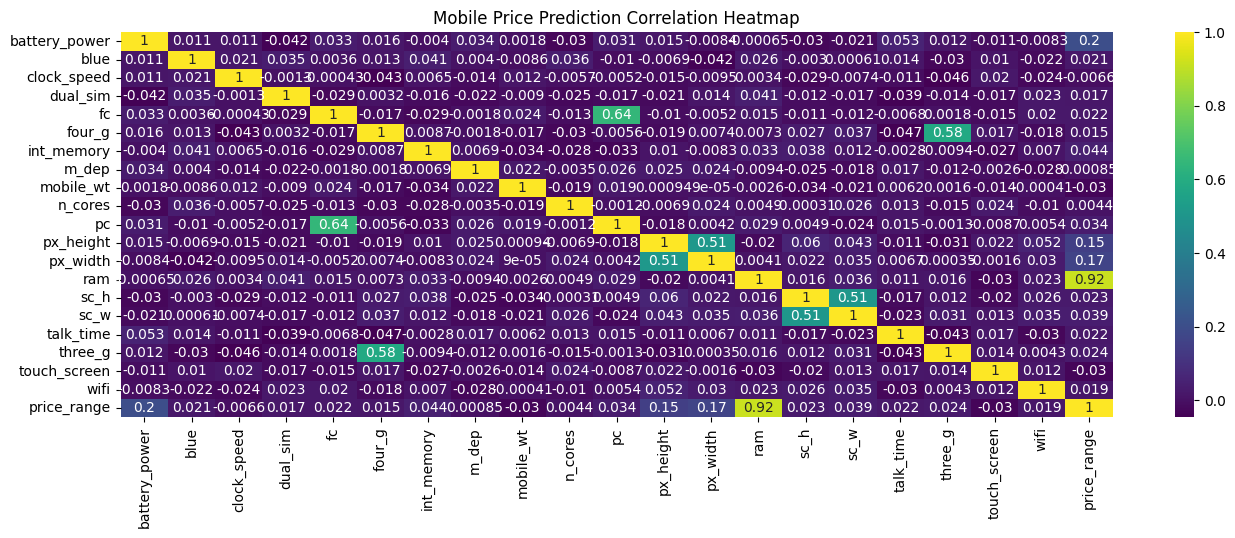

In [85]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16,5))
sns.heatmap(corr, annot=True, cmap="viridis")
plt.title("Mobile Price Prediction Correlation Heatmap")
plt.show()

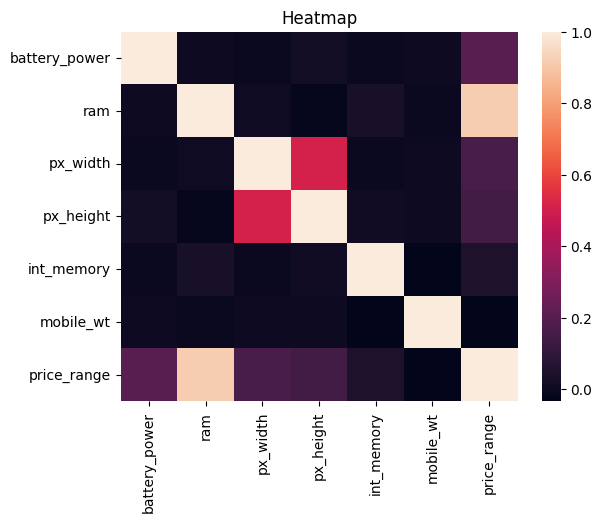

In [86]:
features = ['battery_power','ram','px_width','px_height','int_memory','mobile_wt','price_range']

sns.heatmap(df[features].corr())
plt.title("Heatmap")
plt.show()

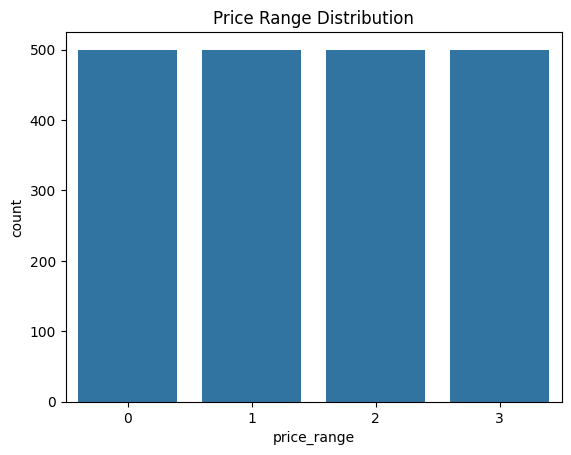

In [87]:
sns.countplot(x=df["price_range"])
plt.title("Price Range Distribution")
plt.show()

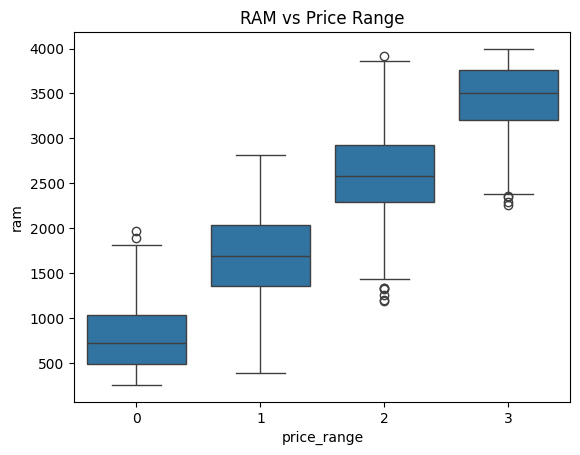

In [88]:
sns.boxplot(x=df["price_range"], y=df["ram"])
plt.title("RAM vs Price Range")
plt.show()

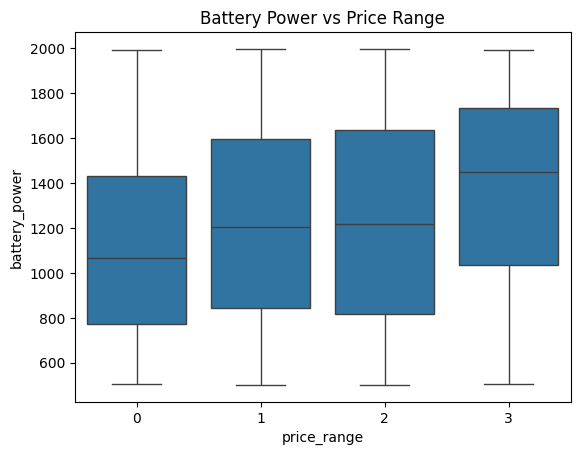

In [89]:
sns.boxplot(x=df["price_range"], y=df["battery_power"])
plt.title("Battery Power vs Price Range")
plt.show()

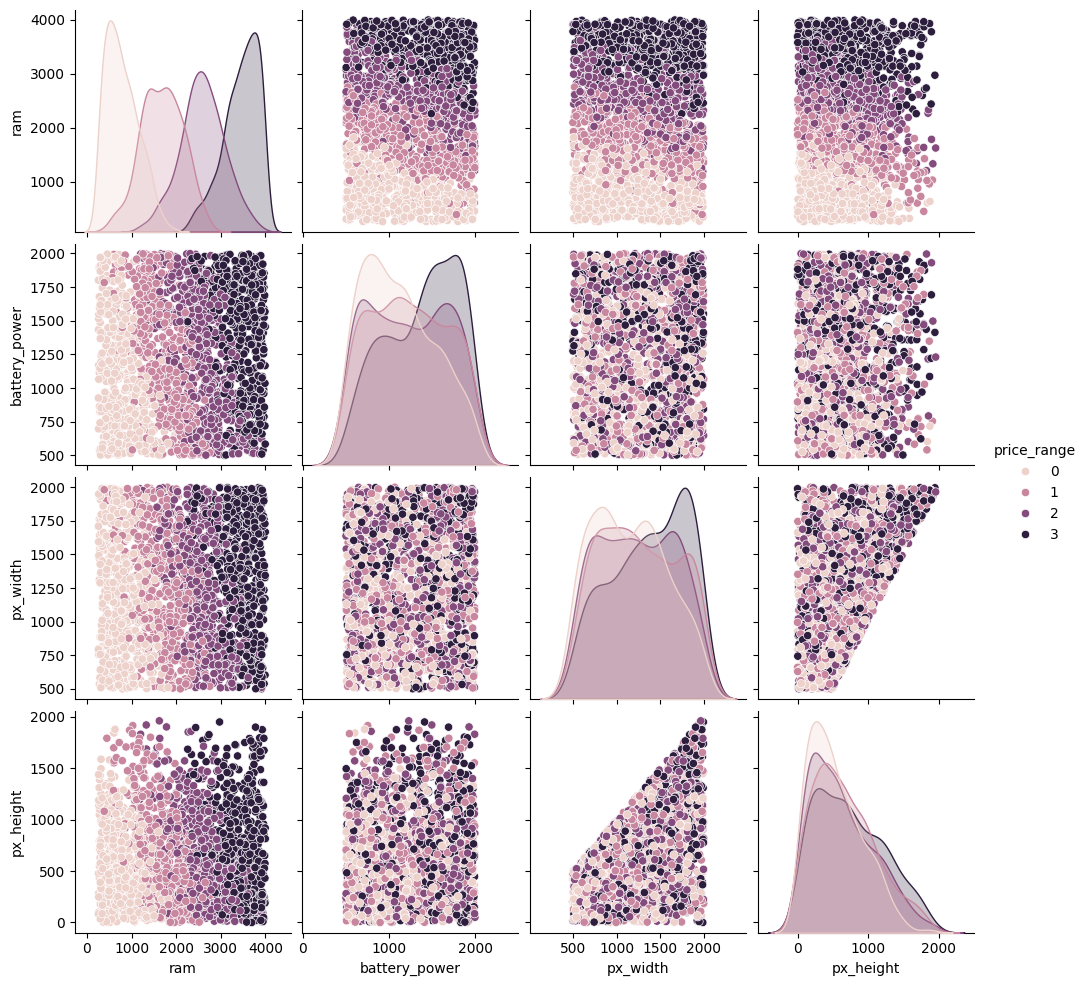

In [90]:
sns.pairplot(df, hue="price_range", vars=["ram","battery_power","px_width","px_height"])
plt.show()

In [91]:
from sklearn.model_selection import cross_val_score

for model in [
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    KNeighborsClassifier(),
    LogisticRegression(max_iter=10000)
]:
    scores = cross_val_score(model, X, y, cv=5)
    print(model.__class__.__name__, scores.mean())

DecisionTreeClassifier 0.8295
RandomForestClassifier 0.8789999999999999
KNeighborsClassifier 0.9195


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LogisticRegression 0.7645


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [92]:
from sklearn.model_selection import cross_val_score

models = {
    "Decision Tree": model,
    "Random Forest": model_forest2,
    "Voting 1": voting_model1,
    "Voting 2": voting_model2,
    "Voting 3": voting_model3,
    "Voting 4": voting_model4,
    "Voting 5": voting_model5,
    "GridSearch": grid_model,
    "XGBoost": clf_XGB3,
    "AdaBoost": clf_Ada,
    "Bagging": clf_bag,
    "Stacking": st_model,
    "KNN": clf_knn
}

for name, m in models.items():
    scores = cross_val_score(m, X, y, cv=5)
    print(name, scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Decision Tree 0.7645
Random Forest 0.876


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Voting 1 0.841


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

...

Voting 4 0.8865000000000001


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Voting 5 0.9025000000000001
GridSearch 0.842
XGBoost 0.905
AdaBoost 0.5129999999999999
Bagging 0.9259999999999999


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Stacking 0.9265000000000001
KNN 0.925


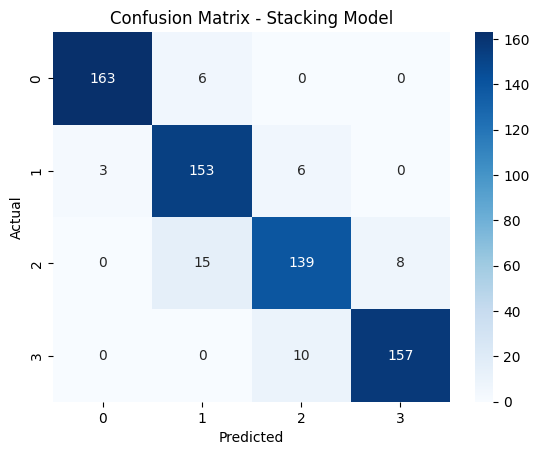

In [93]:
from sklearn.metrics import confusion_matrix

y_pred = st_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Stacking Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

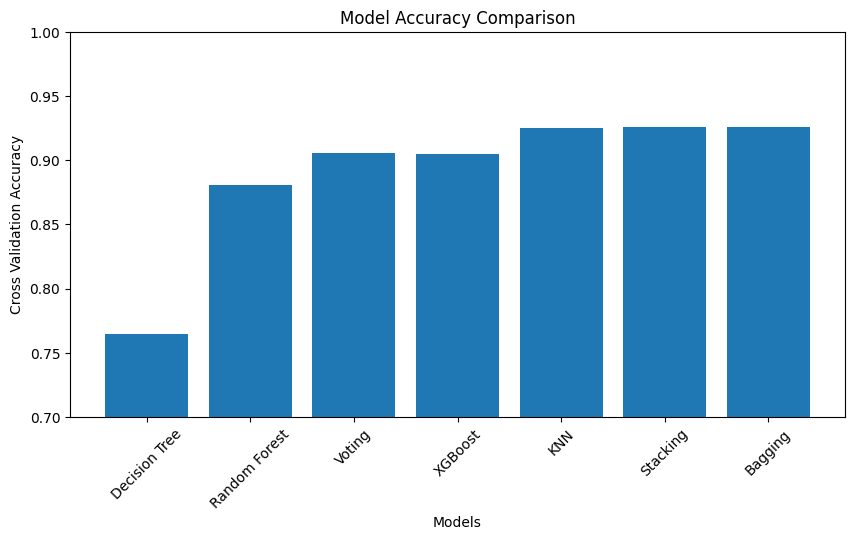

In [94]:
models = [
    "Decision Tree",
    "Random Forest",
    "Voting",
    "XGBoost",
    "KNN",
    "Stacking",
    "Bagging"
]

scores = [
    0.7645,
    0.8805,
    0.9055,
    0.9050,
    0.9250,
    0.9260,
    0.9260
]

plt.figure(figsize=(10,5))
plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Cross Validation Accuracy")
plt.xticks(rotation=45)
plt.ylim(0.7, 1.0)

plt.show()